# Project: Data Scientist Salary Data 2023

## Introduction

The dataset contains salary information for various positions in the data science field.  
describtion of variables：
- work_year：支付薪资的年份
- experience_level：工作年份期间的经验水平  
  **EN**: *entry初级*, **MI**: *mid中级*, **SE**: *senior高级*, **EX**: *executive专家/总监*
- employment_type：职位的就业类型  
  **FT**: *full-time全职,* **PT**: *part-time兼职*, **CT**: *contract合同工,* **FL**: *freelance自由职业者*
- job_title：工作年份期间从事的职位
- salary：支付的总薪资金额
- salary_currency：支付的薪资货币，使用 ISO 4217 货币代码表示
- salary_in_usd：以美元计算的薪资金额
- employee_residence：员工在工作年份期间的主要居住国家，使用 ISO 3166 国家代码表示
- remote_ratio：远程工作的整体比例  
  **0**, **50**, **100**
- company_location：雇主总部所在国家或分支机构所在国家
- company_size：公司在工作年份期间的员工人数的中位数

## Read data

In [1]:
import pandas as pd
ori_d = pd.read_csv("E:\\Python\\ori_dataset_Carmen\\ds_salaries.csv")
ori_d.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
7,2023,SE,FT,Data Scientist,219000,USD,219000,CA,0,CA,M
8,2023,SE,FT,Data Scientist,141000,USD,141000,CA,0,CA,M
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M


## Evaluate and clean data

### 1. Evaluate data tidiness

Looking at a sample of 9 rows, the data confirms to NF-3.There are no structural issues.

### 2. Evaluate data cleanliness

In [2]:
ori_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [3]:
ori_d['remote_ratio'].value_counts()

0      1923
100    1643
50      189
Name: remote_ratio, dtype: int64

From the output, there are a total of 3,755 observations.  
There are no missing values.  
`experience_level`, `employment_type`, `company_size`, `remote_ratio` should be 'category'. **We need to convert their types.**

In [4]:
clean_d = ori_d.copy()
clean_d[['experience_level', 'employment_type', 'company_size', 'remote_ratio']] = clean_d[['experience_level', 'employment_type', 'company_size', 'remote_ratio']].astype('category')
clean_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   work_year           3755 non-null   int64   
 1   experience_level    3755 non-null   category
 2   employment_type     3755 non-null   category
 3   job_title           3755 non-null   object  
 4   salary              3755 non-null   int64   
 5   salary_currency     3755 non-null   object  
 6   salary_in_usd       3755 non-null   int64   
 7   employee_residence  3755 non-null   object  
 8   remote_ratio        3755 non-null   category
 9   company_location    3755 non-null   object  
 10  company_size        3755 non-null   category
dtypes: category(4), int64(3), object(4)
memory usage: 220.8+ KB


#### Evaluate duplicate data

In [5]:
clean_d.duplicated().sum()

1171

There is no employee ID, so duplicated values are normal and require no action.

#### Evaluate inconsistent data

Inconsistent data might be in the `company_location`, `employee_residence`.We need to check if there are multiple different values referring to the same variable.

In [6]:
clean_d['company_location'].value_counts()

US    3040
GB     172
CA      87
ES      77
IN      58
      ... 
MK       1
BS       1
IR       1
CR       1
MT       1
Name: company_location, Length: 72, dtype: int64

In [7]:
clean_d['employee_residence'].value_counts()

US    3004
GB     167
CA      85
ES      80
IN      71
      ... 
BA       1
AM       1
CY       1
KW       1
MT       1
Name: employee_residence, Length: 78, dtype: int64

There are no duplicated values.

#### Evaluate invalid or incorrect data

In [8]:
clean_d.describe()

,work_year,salary,salary_in_usd
count,3755.000000,3.755000e+03,3755.000000
mean,2022.373635,1.906956e+05,137570.389880
std,0.691448,6.716765e+05,63055.625278
min,2020.000000,6.000000e+03,5132.000000
25%,2022.000000,1.000000e+05,95000.000000
50%,2022.000000,1.380000e+05,135000.000000
75%,2023.000000,1.800000e+05,175000.000000
max,2023.000000,3.040000e+07,450000.000000


There are no incorrect values.

## Orgnize data

In [9]:
og_d = clean_d.copy()
og_d = og_d.drop(['salary', 'salary_currency'], axis=1)
og_d.head(2)

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,US,100,US,S


In [10]:
v3_d = og_d[og_d['work_year'] == 2023].copy()
v3_d['work_year'].value_counts()

2023    1785
Name: work_year, dtype: int64

In [11]:
v2_d = og_d[og_d['work_year'] == 2022].copy()
v2_d['work_year'].value_counts()

2022    1664
Name: work_year, dtype: int64

I have orgnized 3 versions of data.I got rid of the useless columns and split it into separate files for 2022 and 2023.

## Explore data

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.figsize'] = [10.00, 6.00]

In [14]:
sns.set_style('whitegrid')

### Salary distribution

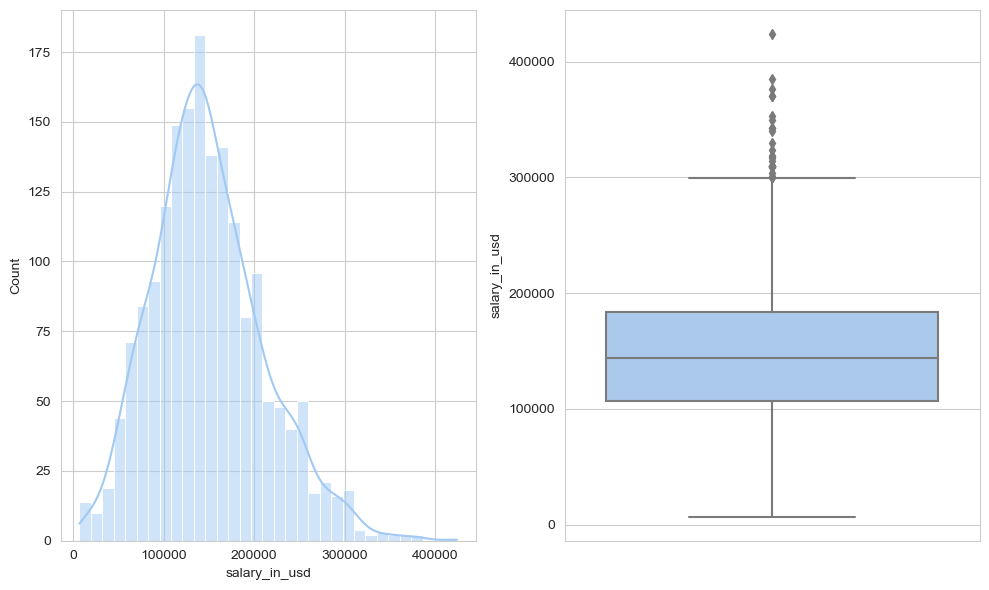

In [15]:
sns.set_palette('pastel')
fig, ax = plt.subplots(1, 2, figsize=[10.00, 6.00])
sns.histplot(data=v3_d, x='salary_in_usd', ax=ax[0], kde=True)
sns.boxplot(data=v3_d, y='salary_in_usd', ax=ax[1])
plt.show()

The data is right-skewed.

### Experience vs salary.

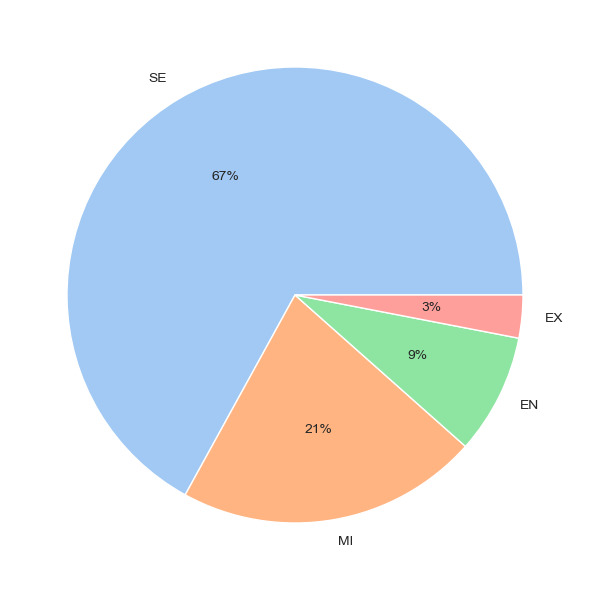

In [22]:
e_num = og_d['experience_level'].value_counts()
plt.pie(e_num, autopct='%.0f%%', labels=e_num.index)
plt.show()

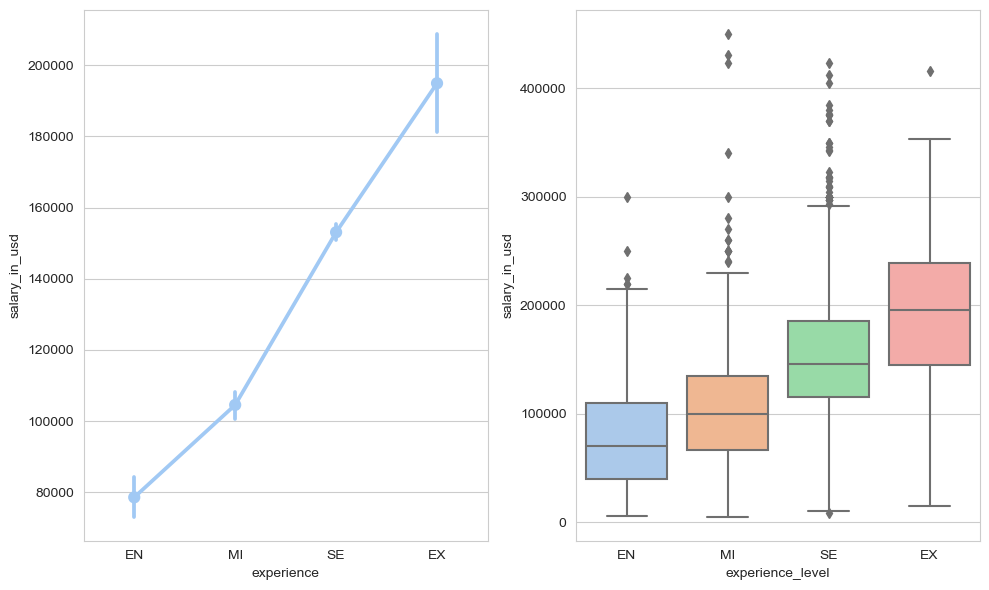

In [38]:
fig, axes = plt.subplots(1, 2)
sns.pointplot(data=og_d,
             x='experience', y='salary_in_usd',
             order=['EN', 'MI', 'SE', 'EX'], ax=axes[0])
sns.boxplot(data=og_d,
            x='experience_level', y='salary_in_usd', 
            ax=axes[1], order=['EN', 'MI', 'SE', 'EX'])
plt.show()

Most scientists are at SE level, with only a few being EN or EX level.  
Salary goes up with experience.

### Compony size vs salary

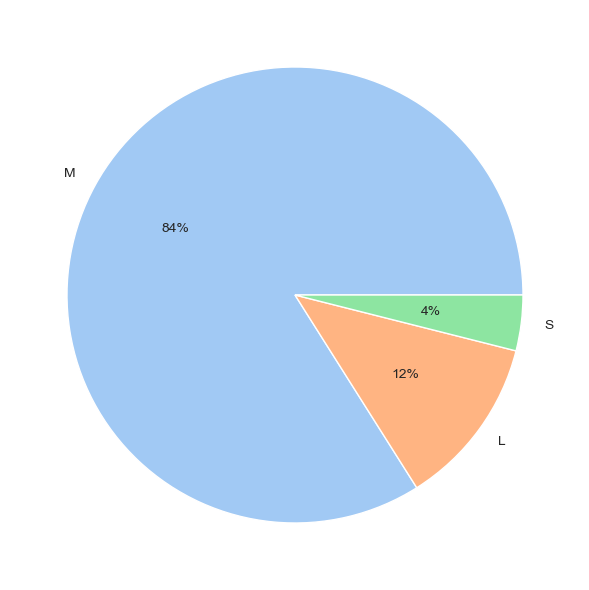

In [43]:
size_num = og_d['company_size'].value_counts()
plt.pie(size_num, autopct='%.0f%%', labels=size_num.index)
plt.show()

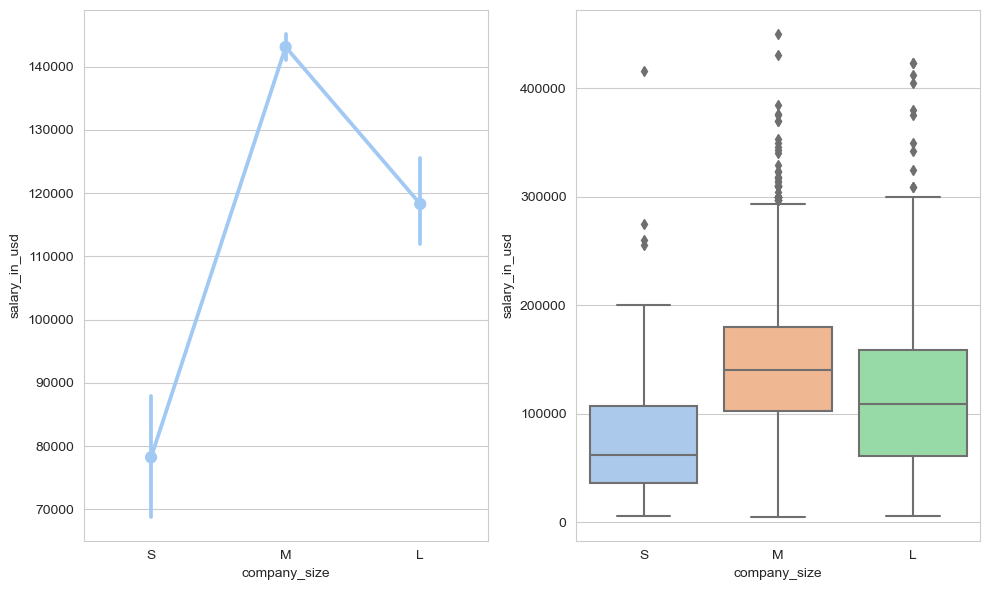

In [45]:
fig, axes = plt.subplots(1, 2)
sns.pointplot(data=og_d,
             x='company_size', y='salary_in_usd',
             order=['S', 'M', 'L'], ax=axes[0])
sns.boxplot(data=og_d,
            x='company_size', y='salary_in_usd', 
            ax=axes[1], order=['S', 'M', 'L'])
plt.show()

Most componies are at M level.  
Componies at M level have the highest salary.

In [40]:
og_d.head(1)

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience
0,2023,SE,FT,Principal Data Scientist,85847,ES,100,ES,L,SE


### 